# Importations

In [43]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience

import pims
import trackpy as tp

import cv2

from tqdm import tqdm
import os
import shutil
import time 

In [44]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
mpl.rc('figure',  figsize=(10, 5))
mpl.rc('image', cmap='gray')
mpl.rc('text', usetex=True)

In [45]:
import sys
sys.path.append("/home/nfares/postdoc/experiments/tracking/")

import trackpy_parallel as tpp

# Auxiliary functions

In [46]:
def normalize8(I):
    mn = I.min()
    mx = I.max()
    I = ((I - mn) / (mx - mn)) * 255
    return I.astype(np.uint8)

# Inputs

In [249]:
# Where to find the data
# path2vid = '/mnt/share/nfares/group/palacgrp/Nicolas/20260528_rotation_in_THF/3p6_3p0.mp4'
path2vid = '/home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4'

# Frame rate
fps = 500

# Pixel size (in m)
px = 130e-9

# Get the frames 

In [250]:
@pims.pipeline
def gray(image, channel=2):
    return image[:, :, channel]  # Take just one channel
    # return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

frames = gray(pims.open(path2vid))
# frames = pims.open(path2vid)

# PyAV-based reading

In [251]:
frames

(PyAVReaderTimed,) processed through proc_func. Original repr:
    <Frames>
    Format: QuickTime / MOV
    Source: /home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4
    Duration: 45.393 seconds
    Frame rate: 1000.022 fps
    Length: 45394 frames
    Frame Shape: (192, 288, 3)
    

In [252]:
len(frames)

45394

# Compute the background

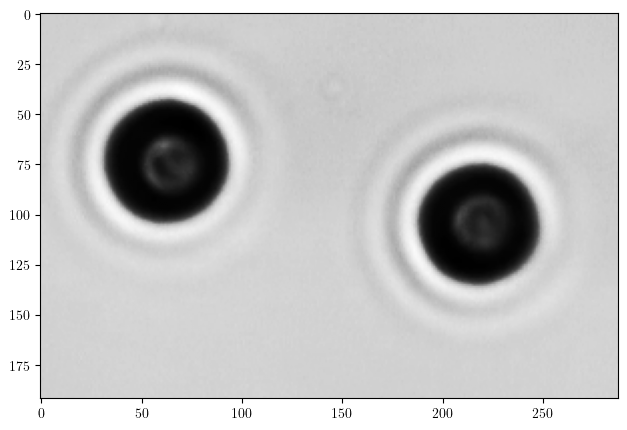

In [253]:
indexes = np.arange(0, 800, 10)
bg = np.median(frames[indexes], axis=0)
plt.figure()
plt.imshow(bg)
plt.show()

In [254]:
# Uncomment next cell if you want to load the background

In [255]:
# bg = cv2.imread('background.tiff')
# bg = gray(bg)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [54]:
# Uncomment next cell if you want to use a ''black'' background

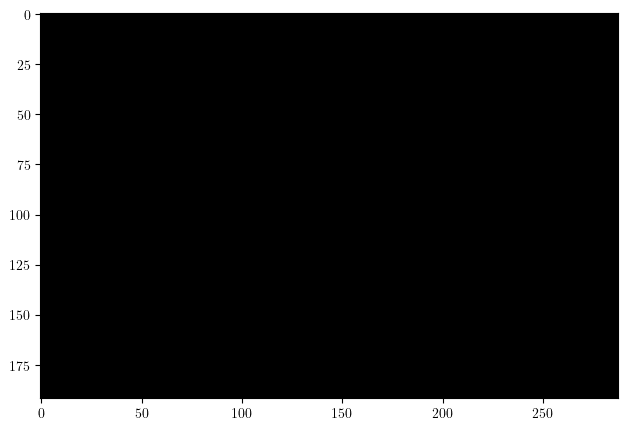

In [256]:
bg = np.zeros_like(frames[0])

plt.figure()
plt.imshow(bg)
plt.show()

# One image: Track Particles

In [444]:
index = 220

In [445]:
im1 = frames[index]

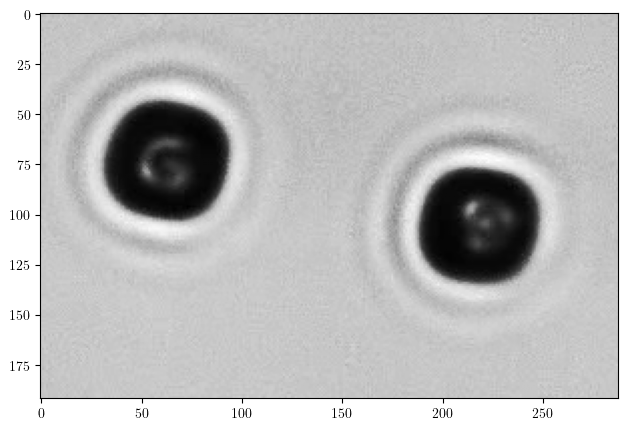

In [446]:
plt.imshow(im1);

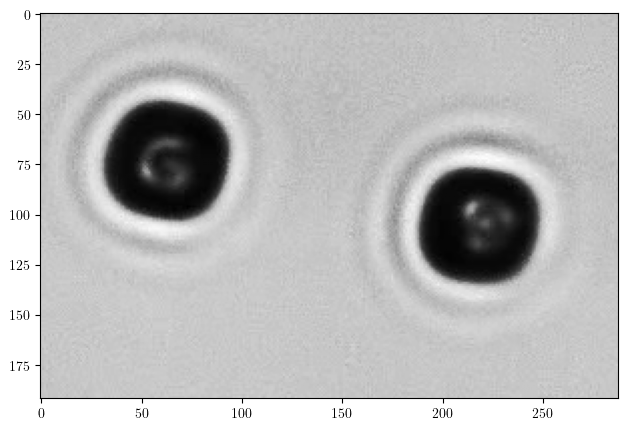

In [447]:
# im2 = (im1 - bg) 
im2 = im1
plt.imshow(im2)

In [448]:
# im2

In [449]:
f2 = tp.locate(im2, 95, invert=True, engine='python')

In [450]:
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,73.305483,63.135869,328197.944676,25.599387,0.069822,135.330094,916160.0,NaN,220
1,105.914700,217.933337,314010.750634,22.526395,0.036694,136.399897,901038.0,NaN,220


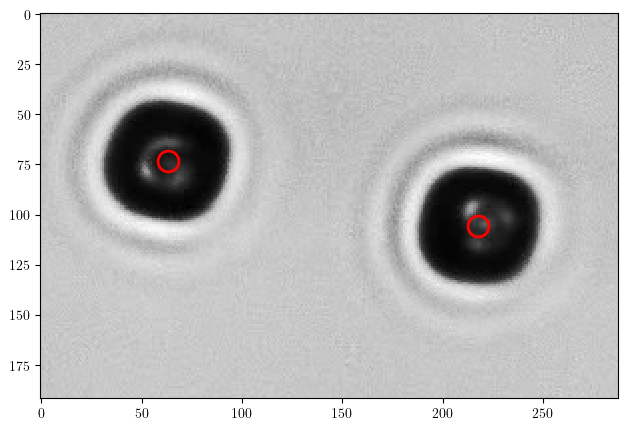

In [451]:
tp.annotate(f2, im2);

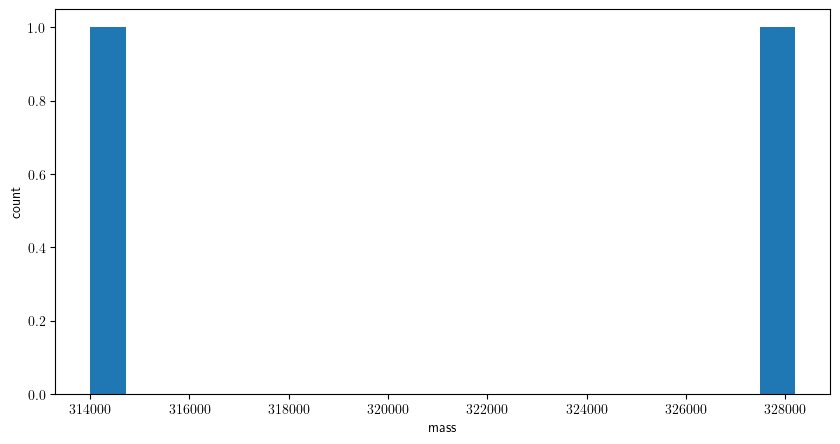

In [452]:
fig, ax = plt.subplots()
ax.hist(f2['mass'], bins=20)

# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

In [453]:
f2 = tp.locate(im2, 95, invert=True, minmass=3000, separation=95)
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,73.305483,63.135869,328197.944676,25.599387,0.069822,135.330094,916160.0,NaN,220
1,105.914700,217.933337,314010.750634,22.526395,0.036694,136.399897,901038.0,NaN,220


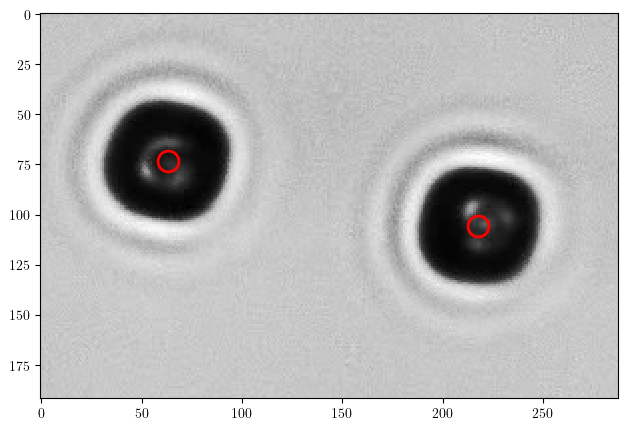

In [454]:
tp.annotate(f2, im2);

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

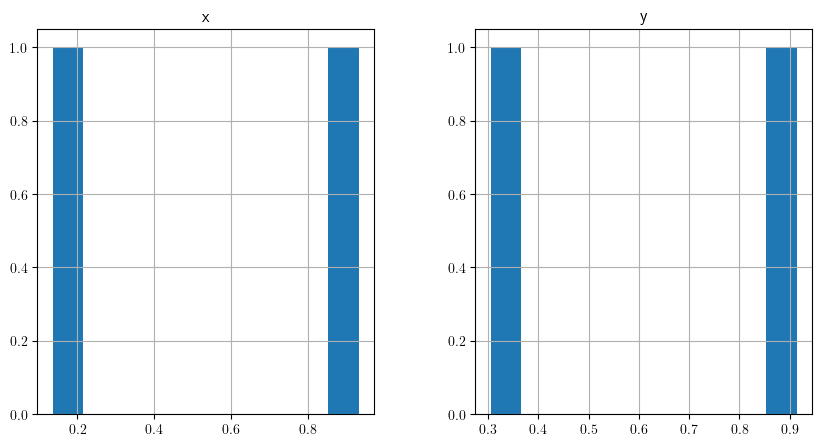

In [455]:
# Check sub-pixel accuracy
tp.subpx_bias(f2)
# Here I changed DataFrame.applymap to DataFrame.map in the source code, because of an update in pandas.
# Source code:
# ~/miniforge3/envs/ista/lib/python3.12/site-packages/trackpy/plots.py

In [456]:
frame = im2

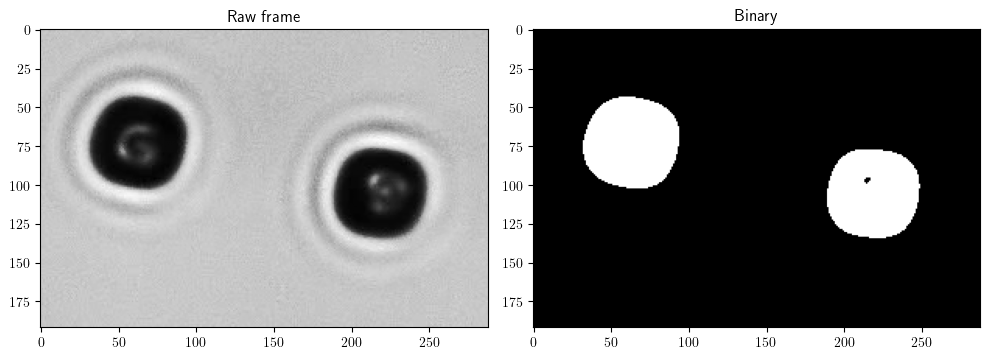

In [457]:
# --- tune these ---
BLUR_SIGMA     = 1.5
THRESH_METHOD  = 'otsu'   # 'otsu' | 'manual'
THRESH_VALUE   = 128      # used only when THRESH_METHOD == 'manual'
# ------------------

def make_binary(frame, blur_sigma=1.5, thresh_method='otsu', thresh_value=128, invert=True):
    ksize = int(6 * blur_sigma) | 1
    blurred = cv2.GaussianBlur(frame, (ksize, ksize), blur_sigma)
    if thresh_method == 'otsu':
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, binary = cv2.threshold(blurred, thresh_value, 255, cv2.THRESH_BINARY)
    if invert: 
        binary = 255 - binary
    return binary

binary = make_binary(im2, blur_sigma=BLUR_SIGMA, thresh_method=THRESH_METHOD, thresh_value=THRESH_VALUE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(im2, cmap='gray');   axes[0].set_title('Raw frame')
axes[1].imshow(binary, cmap='gray');  axes[1].set_title('Binary')
plt.tight_layout()

In [458]:
# Trackpy on the binary image

f3 = tp.locate(binary, 95, invert=False, separation=39)
f3.head()

,y,x,mass,size,ecc,signal,raw_mass,ep
0,73.029354,63.768816,483752.087695,27.930309,0.184734,182.659008,726750.0,0.0
1,105.780692,218.197365,482315.460099,27.118983,0.174616,184.833520,712725.0,0.0


In [459]:
# Find contour

MIN_CONTOUR_POINTS = 10

def find_contours(binary, min_contour_point=10):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = [c for c in contours if len(c) >= min_contour_point]
    return contours

contours = find_contours(binary, min_contour_point=MIN_CONTOUR_POINTS)

print(f"{len(contours)} contours found")

2 contours found


In [460]:
# Find orientation

def _pca_orientation(contour: np.ndarray) -> dict:
    """
    Fit PCA to contour points and return orientation + centroid.

    Parameters
    ----------
    contour : np.ndarray, shape (N, 1, 2)
        Output of cv2.findContours.

    Returns
    -------
    dict with keys:
        cx, cy  : centroid (float)
        theta   : angle in [0, 180) degrees from x-axis
        eigvec  : (2,) principal eigenvector (unit vector)
    """
    pts = contour.reshape(-1, 2).astype(np.float64)   # (N, 2)
    cx, cy = pts.mean(axis=0)

    centered = pts - [cx, cy]
    cov = np.cov(centered.T)                           # (2, 2)
    eigvals, eigvecs = np.linalg.eigh(cov)             # eigvecs[:,i] is i-th vector

    # Principal axis = eigenvector with largest eigenvalue
    principal = eigvecs[:, np.argmax(eigvals)]         # (2,) unit vector

    # Angle from x-axis in [0, 180)
    theta = np.degrees(np.arctan2(principal[1], principal[0])) % 180

    return {"cx": cx, "cy": cy, "theta": theta, "eigvec": principal}

def pca_orientation(contours):
    return [_pca_orientation(c) for c in contours]

results = pca_orientation(contours)

for r in results[:5]:   # preview first 5
    print(f"  centroid=({r['cx']:.1f}, {r['cy']:.1f})  θ={r['theta']:.1f}°")

  centroid=(218.2, 105.8)  θ=165.2°
  centroid=(63.0, 73.2)  θ=170.2°


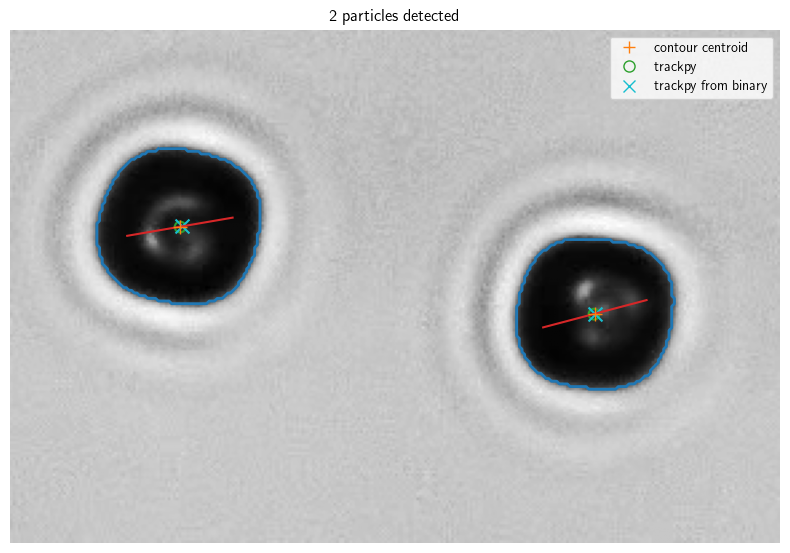

In [461]:
# Plot

ARROW_LEN = 20   # half-length of orientation line in pixels

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(im2, cmap='gray')

for cnt, r in zip(contours, results):
    pts = cnt.reshape(-1, 2)
    ax.plot(pts[:, 0], pts[:, 1], '-', c='tab:blue', linewidth=2, alpha=1)

    cx, cy, ev = r['cx'], r['cy'], r['eigvec']
    ax.plot(
        [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
        [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
        '-', c='tab:red', linewidth=1.5
    )
    ax.plot(cx, cy, '+', mec='tab:orange', markersize=10)

ax.scatter(f2['x'], f2['y'], s=60, facecolors='none', edgecolors='tab:green', linewidths=1.5)
ax.scatter(f3['x'], f3['y'], s=100, marker='x', color='tab:cyan', linewidths=1.5)

ax.legend(handles=[
    plt.Line2D([0], [0], marker='+', color='tab:orange', linestyle='None', markersize=8, label='contour centroid'),
    plt.Line2D([0], [0], marker='o', color='tab:green', linestyle='None', markersize=8, markerfacecolor='none', label='trackpy'),
    plt.Line2D([0], [0], marker='x', color='tab:cyan', linestyle='None', markersize=8, markerfacecolor='none', label='trackpy from binary'),
], loc='upper right')

ax.set_title(f'{len(results)} particles detected')
ax.axis('off')
plt.tight_layout()

In [462]:
# Add orientation to trackpy 

MAX_MATCH_DISTANCE = 5.0   # pixels

def match_orientations(tp_frame: pd.DataFrame, results: list[dict], max_dist: float) -> pd.DataFrame:
    """
    Attach orientation to each trackpy detection by nearest centroid.
    Unmatched detections get theta = NaN.
    """
    tp_frame = tp_frame.copy()
    tp_frame['theta'] = np.nan

    if not results:
        return tp_frame

    ell_xy = np.array([[r['cx'], r['cy']] for r in results])

    for idx, row in tp_frame.iterrows():
        dists = np.hypot(ell_xy[:, 0] - row['x'], ell_xy[:, 1] - row['y'])
        best = int(np.argmin(dists))
        if dists[best] <= max_dist:
            tp_frame.at[idx, 'theta'] = results[best]['theta']

    return tp_frame

tp_frame = match_orientations(f2, results, MAX_MATCH_DISTANCE)
print(tp_frame[['x', 'y', 'theta']].head(10))

            x           y       theta
0   63.135869   73.305483  170.220727
1  217.933337  105.914700  165.218447


In [463]:
def _moments_orientation(contour: np.ndarray, binary: np.ndarray) -> dict:
    """
    Compute orientation from image moments of the filled particle region.
    Uses the second-order central moments (inertia tensor) of the masked pixels,
    which reflects the bulk mass distribution rather than the boundary shape.

    Parameters
    ----------
    contour : np.ndarray, shape (N, 1, 2)
        Single contour from cv2.findContours.
    binary : np.ndarray, dtype=uint8
        Full binary mask (used to extract the filled region).

    Returns
    -------
    dict with keys:
        cx, cy : centroid (float)
        theta  : angle in [0, 180) degrees from x-axis
                 NaN if the shape is too symmetric (mu20 == mu02 and mu11 == 0)
    """
    # Draw filled mask for this contour only
    mask = np.zeros_like(binary)
    cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    M = cv2.moments(mask)

    if M["m00"] == 0:
        return {"cx": np.nan, "cy": np.nan, "theta": np.nan}

    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]

    # Second-order central moments
    mu20 = M["mu20"] / M["m00"]
    mu02 = M["mu02"] / M["m00"]
    mu11 = M["mu11"] / M["m00"]

    # Orientation of the inertia tensor principal axis
    theta_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
    theta = np.degrees(theta_rad) % 180

    return {"cx": cx, "cy": cy, "theta": theta}

def moments_orientation(contours, binary):
    return [_moments_orientation(c, binary) for c in contours]

results_moments = moments_orientation(contours, binary)

for r in results_moments[:5]:
    print(f"  centroid=({r['cx']:.1f}, {r['cy']:.1f})  θ={r['theta']:.1f}°")

  centroid=(218.2, 105.7)  θ=165.5°
  centroid=(62.9, 73.2)  θ=171.1°


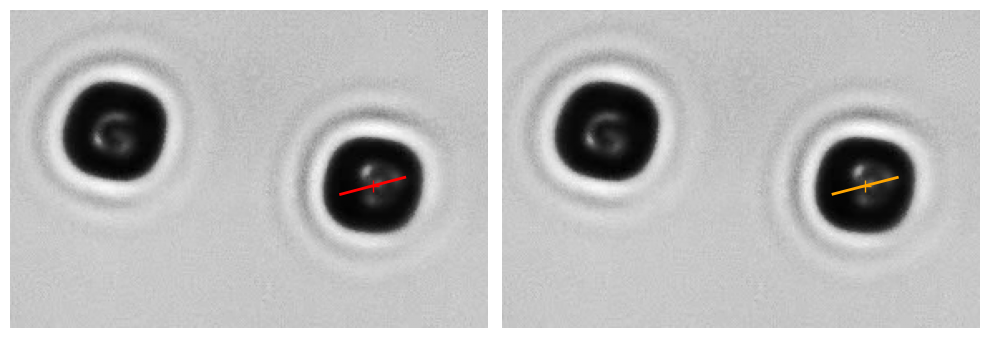

In [464]:
# Pick one particle index to inspect
IDX = 0

r_pca = results[IDX]
r_mom = results_moments[IDX]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, r, label, color in zip(
    axes,
    [r_pca, r_mom],
    ["PCA (contour)", "Moments (filled)"],
    ["red", "orange"],
):
    ax.imshow(frame, cmap="gray")
    cx, cy = r["cx"], r["cy"]

    # Recompute eigvec from theta for plotting
    theta_rad = np.radians(r["theta"])
    ev = np.array([np.cos(theta_rad), np.sin(theta_rad)])

    ax.plot(
        [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
        [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
        color=color, linewidth=2
    )
    ax.plot(cx, cy, "+", color=color, markersize=8)
    # ax.set_title(f"θ = {r["theta"]}°")
    ax.axis("off")

plt.tight_layout()

In [477]:
from skimage.measure import label, regionprops, find_contours

# --- tune this ---
MIN_AREA = 100   # pixels — filters out small noise blobs
MAX_AREA = 5000  # pixels — filters out merged particles
# ------------------

labeled = label(binary)
props = regionprops(labeled)
props = [p for p in props if MIN_AREA < p.area < MAX_AREA]

print(f"{len(props)} particles detected")

# Build a DataFrame in the same format as before
df = pd.DataFrame([{
    "x":     p.centroid[1],              # col → x
    "y":     p.centroid[0],              # row → y
    "theta": np.degrees(p.orientation), # radians → degrees, in [-90, 90]
    "area":  p.area,
    "minor_axis": p.minor_axis_length,
    "major_axis": p.major_axis_length,
} for p in props])

# Convert theta to [0, 180)
df["theta"] = df["theta"] % 180

print(df[["x", "y", "theta", "area"]].head(10))

2 particles detected
            x           y       theta    area
0   62.888136   73.150508   98.923152  2950.0
1  218.259722  105.745986  104.663740  2803.0


/tmp/ipykernel_5803/2181440920.py:20: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis": p.minor_axis_length,
/tmp/ipykernel_5803/2181440920.py:21: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis": p.major_axis_length,


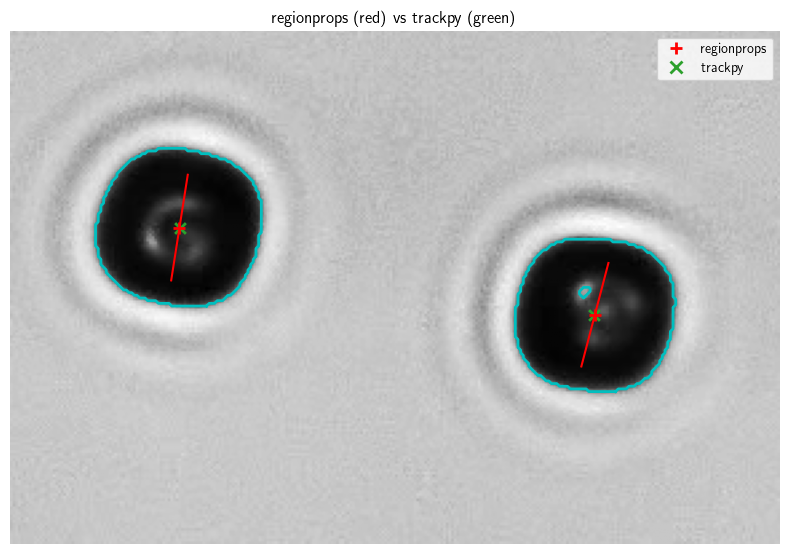

In [479]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(frame, cmap="gray")

# regionprops: centroid + orientation line
for _, row in df.iterrows():
    cx, cy = row["x"], row["y"]
    theta_rad = np.radians(row["theta"])
    ev = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    ax.plot(
        [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
        [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
        "r-", linewidth=1.5, 
    )
    ax.plot(cx, cy, "r+", markersize=8, markeredgewidth=2)

for p in props:
    # Contour of this particle
    particle_mask = labeled == p.label
    contours = find_contours(particle_mask, level=0.5)
    for cnt in contours:
        ax.plot(cnt[:, 1], cnt[:, 0], 'c-', linewidth=2)  # note: cnt is (row, col) → swap for plot

# trackpy: centroid only
ax.scatter(tp_frame["x"], tp_frame["y"], s=60, marker="x",
           color="tab:green", linewidths=2, label="trackpy")

ax.legend(handles=[
    plt.Line2D([0], [0], marker="+", color="red", linestyle="None", markersize=8, markeredgewidth=2, label="regionprops"),
    plt.Line2D([0], [0], marker="x", color="tab:green", linestyle="None", markersize=8, markeredgewidth=2, label="trackpy"),
], loc="upper right")
ax.set_title("regionprops (red) vs trackpy (green)")
ax.axis("off")
plt.tight_layout()

In [472]:
p

array([0, 1])

In [473]:
props

[<RegionProperties: label=1, bbox=(44, 32, 103, 94)>,
 <RegionProperties: label=2, bbox=(78, 189, 135, 249)>]

# Several Images: Tracking and Linking

## Inputs

In [394]:
start = 0
stop = 1500 #len(frames)

In [396]:
R1 = 85 # radius for spot tracking
minmass = 3000
separation = 85
invert = True

In [304]:
n_workers = 1

In [305]:
path2vid

'/home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4'

In [298]:
path2folder = './'

vidname = path2vid[len(path2folder):path2vid.find('.mp4')]
savename = path2folder + 'trajectories_' + vidname
print(savename)

./trajectories_ome/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c


## Perform Tracking

In [299]:
# Define args for input in the tracking function

args = (start, stop, R1, minmass, separation, invert)

In [300]:
# Parallel tracking 

f = tpp.process_video(video_path=path2vid, start=start, stop=stop, args=args, n_workers=n_workers)

2.51 GB will be loaded into shared memory.


  9%|▉         | 4197/45394 [00:41<06:46, 101.40it/s]


KeyboardInterrupt: 

In [301]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta


100%|██████████| 1499/1499 [05:25<00:00,  4.60it/s]


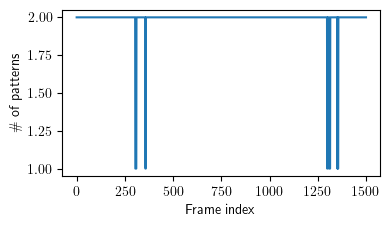

In [397]:
# Track particles in every images, manual version
# The purpose of the manual version is to easily add image modification = work in RAM.  

# Store the number of patterns on each image
count = np.zeros(stop-start)
# Store the tracked patterns in every images
i = start
frame = frames[i]
f = tp.locate(frame, R1, invert=invert, minmass=minmass, separation=separation)
count[i-start] = len(f)

binary = make_binary(frame, blur_sigma=BLUR_SIGMA, thresh_method=THRESH_METHOD, thresh_value=THRESH_VALUE)
contours = find_contours(binary, min_contour_point=MIN_CONTOUR_POINTS)
# angles = pca_orientation(contours)
angles = moments_orientation(contours, binary)

f = match_orientations(f, angles, MAX_MATCH_DISTANCE)

# Loop
for i in tqdm(range(start+1, stop, 1)):
# for i in tqdm(range(1, 2, 1)):
    frame = frames[i]
    ftemp = tp.locate(frame, R1, invert=invert, minmass=minmass, separation=separation)
    # Artificially correct for 
    if ftemp['frame'].iloc[0] != i:
        ftemp = ftemp.reset_index(drop=True)
        for j in range(len(ftemp)):
            ftemp.at[j, 'frame'] = i
    count[i-start] = len(ftemp)

    binary = make_binary(frame, blur_sigma=BLUR_SIGMA, thresh_method=THRESH_METHOD, thresh_value=THRESH_VALUE)
    contours = find_contours(binary, min_contour_point=MIN_CONTOUR_POINTS)
    # angles = pca_orientation(contours)
    angles = moments_orientation(contours, binary)

    ftemp = match_orientations(ftemp, angles, MAX_MATCH_DISTANCE)

    f = pd.concat([f, ftemp], ignore_index=True)

# Plot the nb of patterns per image
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 6/2.54))
ax.plot(np.arange(start, stop, 1), count)
# ax.plot(count)
ax.set(xlabel='Frame index', ylabel=r'\# of patterns')
plt.tight_layout()
plt.show()

In [398]:
f.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta
0,75.098284,62.930367,286236.784997,25.514173,0.090817,128.511657,810613.0,NaN,0,80.815524
1,105.577134,218.439925,285713.666959,24.340315,0.078075,128.007690,808666.0,NaN,0,62.120474
2,74.687432,62.899997,290684.256700,25.318624,0.089811,128.089839,818151.0,NaN,1,80.280160
3,105.574983,218.439164,285716.993257,24.342282,0.078086,128.594130,808697.0,NaN,1,62.120474
4,75.100227,62.929521,286201.112334,25.514711,0.090781,128.089839,810533.0,NaN,2,80.280160


In [399]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta


## Perform linking

In [400]:
# Inputs

search_range = 10
memory = 25

stubs_threshold = 100

In [401]:
# Link trajectories

# tp.quiet()
tracks = tp.link(f, search_range=search_range, memory=memory)

Frame 1499: 2 trajectories present.


In [408]:
tracks.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle
0,75.098284,62.930367,286236.784997,25.514173,0.090817,128.511657,810613.0,NaN,0,80.815524,0
1,105.577134,218.439925,285713.666959,24.340315,0.078075,128.007690,808666.0,NaN,0,62.120474,1
2,74.687432,62.899997,290684.256700,25.318624,0.089811,128.089839,818151.0,NaN,1,80.280160,0
3,105.574983,218.439164,285716.993257,24.342282,0.078086,128.594130,808697.0,NaN,1,62.120474,1
4,75.100227,62.929521,286201.112334,25.514711,0.090781,128.089839,810533.0,NaN,2,80.280160,0


In [409]:
# Filter too-short trajectories

tracks1 = tp.filter_stubs(tracks, threshold=stubs_threshold)
# t1.index.name = None
tracks1 = tracks1.set_index(np.arange(len(tracks1)), drop=True)

In [410]:
tracks1.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle
0,75.098284,62.930367,286236.784997,25.514173,0.090817,128.511657,810613.0,NaN,0,80.815524,0
1,105.577134,218.439925,285713.666959,24.340315,0.078075,128.007690,808666.0,NaN,0,62.120474,1
2,74.687432,62.899997,290684.256700,25.318624,0.089811,128.089839,818151.0,NaN,1,80.280160,0
3,105.574983,218.439164,285716.993257,24.342282,0.078086,128.594130,808697.0,NaN,1,62.120474,1
4,75.100227,62.929521,286201.112334,25.514711,0.090781,128.089839,810533.0,NaN,2,80.280160,0


In [411]:
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', tracks['particle'].nunique())
print('After:', tracks1['particle'].nunique())

Before: 2
After: 2


In [412]:
# Filter with conditions on tracked particles
tracks2 = tracks1[((tracks1['ecc'] < 0.9))]

In [413]:
tracks2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle
0,75.098284,62.930367,286236.784997,25.514173,0.090817,128.511657,810613.0,NaN,0,80.815524,0
1,105.577134,218.439925,285713.666959,24.340315,0.078075,128.007690,808666.0,NaN,0,62.120474,1
2,74.687432,62.899997,290684.256700,25.318624,0.089811,128.089839,818151.0,NaN,1,80.280160,0
3,105.574983,218.439164,285716.993257,24.342282,0.078086,128.594130,808697.0,NaN,1,62.120474,1
4,75.100227,62.929521,286201.112334,25.514711,0.090781,128.089839,810533.0,NaN,2,80.280160,0


In [414]:
print("# of tracked particles = {}".format(tracks2['particle'].nunique()))

# of tracked particles = 2


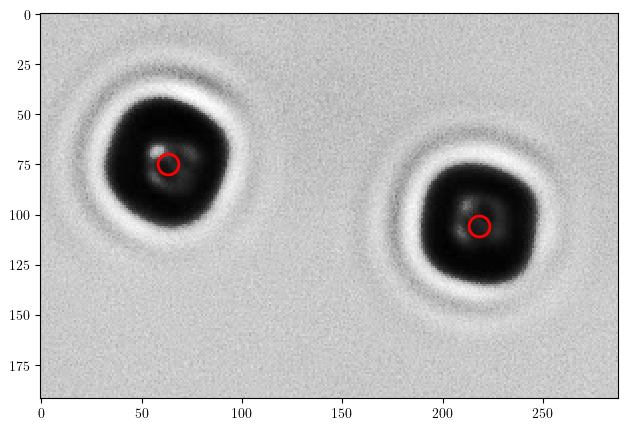

<Axes: >

In [415]:
i = 1
tp.annotate(tracks2[tracks2['frame'] == start+i], frames[start+i])

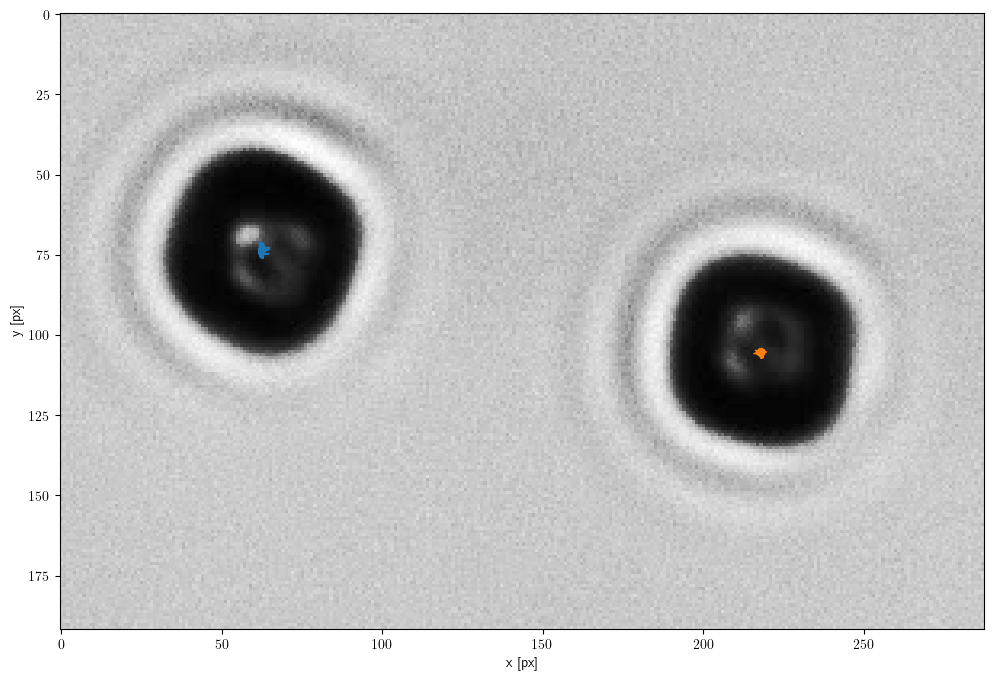

In [416]:
plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
tp.plot_traj(tracks2);

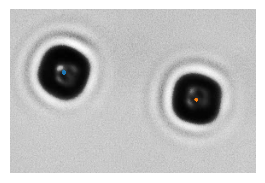

In [417]:
p = tracks2['particle'].unique()
N = tracks2['particle'].nunique()

fig, ax = plt.subplots(figsize=(7/2.54, 7/2.54))
ax.imshow(frames[start])
for i in range(len(p)):
    x = tracks2[tracks2['particle'] == p[i]]['x']
    y = tracks2[tracks2['particle'] == p[i]]['y']
    ax.plot(x, y, linewidth=0.5)
    # plt.annotate(str(p[i]), (x.iloc[0], y.iloc[0]), c='white', size=15)
ax.axis('off')
plt.tight_layout()
plt.show()
# fig.savefig('example_tracking.pdf', dpi=600, bbox_inches='tight')

In [418]:
# Check the displacement between consecutive frames for a given particle
p_id = 0
traj = tracks2[tracks2['particle'] == p_id].sort_values('frame')
traj['dx'] = traj['x'].diff()
traj['dy'] = traj['y'].diff()
traj['displacement'] = (traj['dx']**2 + traj['dy']**2)**0.5
print(traj['displacement'].max() / (px*1e6))

30.639297856762568


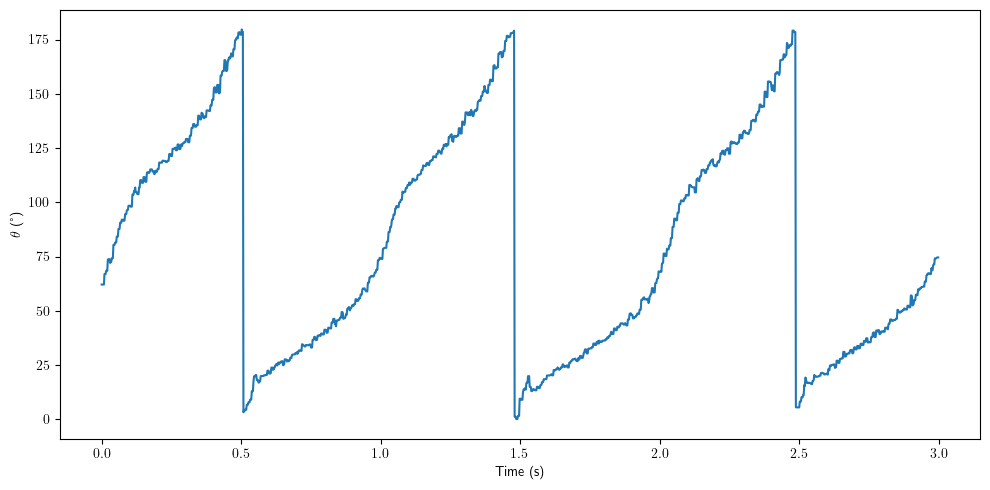

In [419]:
p_id = 1

traj = tracks[tracks['particle'] == p_id].sort_values('frame')

theta = traj['theta'].to_numpy()
time = traj['frame'].to_numpy() / fps 

fig, ax = plt.subplots(1, 1)
ax.plot(time, theta)
ax.set(xlabel='Time (s)', ylabel=r'$\theta$ (°)')
plt.tight_layout()
plt.show()


In [420]:
np.nanstd(theta)

np.float64(50.46653682719714)

In [421]:
np.nanstd(theta) / 360 * 100

np.float64(14.018482451999207)

In [425]:
def _unwrap_theta(theta):
    res = np.copy(theta)
    res = np.radians(res)
    res[~np.isnan(res)] = np.unwrap(res[~np.isnan(res)], period=np.pi)
    res = np.degrees(res)
    res = res % 360 
    return res 

def unwrap_theta(tracks: pd.DataFrame) -> pd.DataFrame:
    res = tracks.copy()
    res['theta_unwrapped'] = (
        tracks.groupby('particle')['theta']
        .transform(_unwrap_theta)
    )
    return res

In [426]:
tracks3 = unwrap_theta(tracks2)

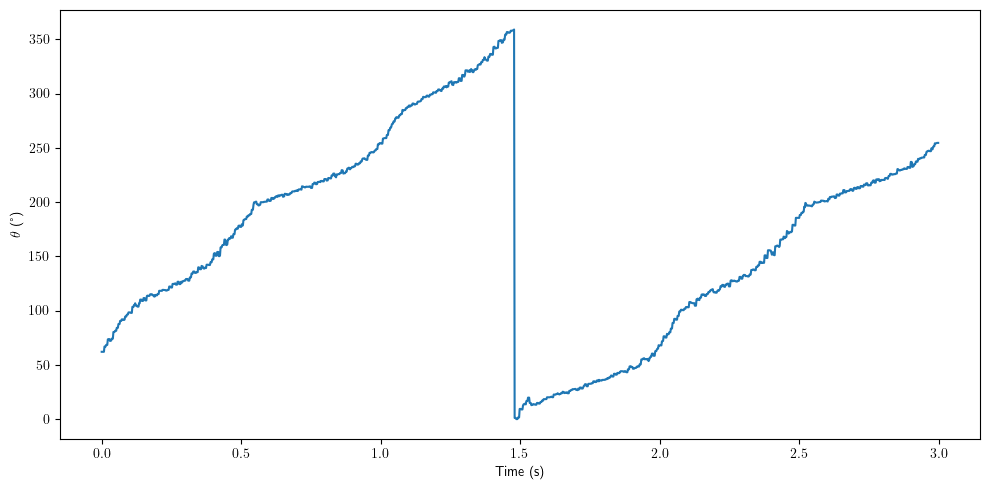

In [427]:
traj = tracks3[tracks3['particle'] == p_id].sort_values('frame')

theta = traj['theta_unwrapped'].to_numpy()
time = traj['frame'].to_numpy() / fps 

fig, ax = plt.subplots(1, 1)
ax.plot(time, theta)
ax.set(xlabel='Time (s)', ylabel=r'$\theta$ (°)')
plt.tight_layout()
plt.show()

In [393]:
tracks3.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle,theta_unwrapped
0,78.122692,62.822408,226916.730709,23.318565,0.010507,120.414432,680916.0,NaN,0,80.815524,0,80.815524
1,108.326750,218.753760,230109.609451,22.814442,0.005822,120.414432,684557.0,NaN,0,62.120474,1,62.120474
2,78.129289,62.819368,226857.450717,23.314756,0.010756,120.320634,680819.0,NaN,1,80.280160,0,80.280160
3,107.772164,218.745975,235681.595515,22.800902,0.007956,120.320634,694052.0,NaN,1,62.120474,1,62.120474
4,78.129301,62.818766,226859.345530,23.314556,0.010760,120.320634,680801.0,NaN,2,80.280160,0,80.280160


In [348]:
tracks2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle
0,78.122692,62.822408,226916.730709,23.318565,0.010507,120.414432,680916.0,NaN,0,80.815524,0
1,108.326750,218.753760,230109.609451,22.814442,0.005822,120.414432,684557.0,NaN,0,62.120474,1
2,78.129289,62.819368,226857.450717,23.314756,0.010756,120.320634,680819.0,NaN,1,80.280160,0
3,107.772164,218.745975,235681.595515,22.800902,0.007956,120.320634,694052.0,NaN,1,62.120474,1
4,78.129301,62.818766,226859.345530,23.314556,0.010760,120.320634,680801.0,NaN,2,80.280160,0


In [349]:
tracks.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,theta,particle
0,78.122692,62.822408,226916.730709,23.318565,0.010507,120.414432,680916.0,NaN,0,80.815524,0
1,108.326750,218.753760,230109.609451,22.814442,0.005822,120.414432,684557.0,NaN,0,62.120474,1
2,78.129289,62.819368,226857.450717,23.314756,0.010756,120.320634,680819.0,NaN,1,80.280160,0
3,107.772164,218.745975,235681.595515,22.800902,0.007956,120.320634,694052.0,NaN,1,62.120474,1
4,78.129301,62.818766,226859.345530,23.314556,0.010760,120.320634,680801.0,NaN,2,80.280160,0
